# Deliverable 2: Bayesian Spatial Search Problem
**University of Barcelona**
**Bayesian Statistics and Probabilistic Programming**

---

## Overview

We construct a Bayesian model for recovering lost objects at the sea.
First we start buiding a **prior distribution** over the cells of the grid from objective knowledge of the accident (explosion point, velocity, wind and drift) and two witness statements.
After this, we define a **detection probability** model based on the previous mission reports, we run three search missions, update the beliefs sequentially and propose a **final new search mission**.

---

## 0. Setup and data loading

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import multivariate_normal, chi2

# Reproducibility
np.random.seed(42)

# Fixed problem constraints
Nx, Ny = 50, 35 # grid dimensions
BUDGET = 1000 # how much can be spent on the search

# Accident information (given in the initial notebook)
x_E = np.array([7.0, 20.0]) # explosion point
v_plane = np.array([6.0, -3.5]) # aircraft velocity
v_wind = np.array([-1.0, -1.5]) # wind vector
v_drift = np.array([0.5, -1.5]) # water drift/current

# Grid dataset
grid_df = pd.read_csv("grid_dataset.csv")
print(f"Grid: {grid_df.shape[0]} cells ({Nx}x{Ny})")
grid_df.head(3)

Grid: 1750 cells (50x35)


,cell_id,x,y,depth,roughness
0,0,0.5,0.5,0.000000,0.387418
1,1,1.5,0.5,0.037815,0.379730
2,2,2.5,0.5,0.075630,0.389246


---

## Task 1: Prior distributions

### Physical motivation

The object fell from the aircraft at the explosion point $\mathbf{x}_E = (7, 20)$.
Two phases affect the object before it rests on the seafloor, acting in sequence.

---

**Phase 1: Aerial drift**. After the object is detached from the airplane, it first carries the full horizontal momentum of the aircraft so its initial horizontal velocity is $\mathbf{v}_{\text{plane}}$. While the object is in the air, it is also subject to the aerodynamic drag from the surrounding air mass, which moves at $\mathbf{v}_{\text{wind}}$. The drag force points opposite to the relative velocity between the object and the air, and is proportional to its magnitude:

$$\mathbf{F}_{\text{drag}} = -\frac{m}{\tau}\bigl(\mathbf{v}(t) - \mathbf{v}_{\text{wind}}\bigr),$$

where $m$ is the object's mass and $\tau$ is the drag timescale; a single number that absorbs the object's shape, size, mass and air density. Large $\tau$ means weak drag (heavy, smooth object), while small $\tau$ means strong drag (light object).

Applying Newton's second law:

$$\text{m} \dot{\text{v}} = \text{F}_\text{drag} = - \tfrac{m}{\tau}\ (\text{v(t)} - \text{v}_\text{wind}).$$

And dividing by $\text{m}$:

$$\dot{\text{v}} = - \tfrac{1}{\tau}\ (\text{v(t)} - \text{v}_\text{wind}).$$

Defining $\mathbf{u}(t) = \mathbf{v}(t) - \mathbf{v}_{\text{wind}}$ (velocity relative to the wind). Then $\dot{\mathbf{u}} = \dot{\mathbf{v}}$, so the equation becomes:

$$\dot{\mathbf{u}} = -\frac{1}{\tau}\,\mathbf{u},$$

This is exponential decay. Its solution is:

$$\mathbf{u}(t) = \mathbf{u}(0)\,e^{-t/\tau}, \qquad \text{i.e.} \qquad \mathbf{v}(t) = \mathbf{v}_{\text{wind}} + \bigl(\mathbf{v}_{\text{plane}} - \mathbf{v}_{\text{wind}}\bigr)e^{-t/\tau}.$$

At $t = 0$, $\mathbf{v} = \mathbf{v}_{\text{plane}}$ (the object carries the aircraft's velocity). As $t \to \infty$, $\mathbf{v} \to \mathbf{v}_{\text{wind}}$ (the drag has fully coupled the object to the air). The timescale over which this happens it $\tau$.

We will suppose that the fall duration is $T_{\text{air}} \ll \tau$ (heavy object, short fall, the object hits the water before the drag has much effect). In this case, the exponential can be approximated by its first-order Taylor expansion $e^{-t/\tau} \approx 1 - t/\tau$, giving:

$$\mathbf{v}(t)≈\mathbf{v}_{wind}​+(\mathbf{v}_{plane​}−\mathbf{v}_{wind}​)(1−\frac{t}{\tau}​).$$

Integrating to get the displacement:

$$\Delta\mathbf{x}_{\text{air}}
= \int_0^{T_{\text{air}}} {\mathbf{v(t)}}\,dt
\approx \mathbf{v}_{\text{plane}}\,T_{\text{air}}
  + \tfrac{1}{2}\,\bigl(\mathbf{v}_{\text{wind}} - \mathbf{v}_{\text{plane}}\bigr)\,\frac{T_{\text{air}}^2}{\tau}.$$

Because $T_{\text{air}}/\tau \ll 1$, the second term is small relative to the first.
Writing the effective wind contribution as
$w_{\text{wind}}\,\mathbf{v}_{\text{wind}}\,T_{\text{air}}$ and absorbing everything into
the weights, the wind contribution is *at most* $\tfrac{T_{\text{air}}}{2\tau}$ times the
plane contribution. Strictly less than the plane's, and strictly positive.

---

**Phase 2: Aquatic drift**. After impact with the water, the object floats while the current carries it at $\mathbf{v}_{\text{drift}}$
for a duration $T_{\text{drift}}$ before sinking. By the same drag-coupling argument (now between the object and the water), the effective drift displacement is:

$$\Delta\mathbf{x}_{\text{drift}} \approx \mathbf{v}_{\text{drift}}\,T_{\text{drift}}.$$

Here we don't have any ½ factor because we assume that the object hits the water still moving fast horizontally at roughly $\mathbf{v}_{\text{plane}}$, which is much larger than $\mathbf{v}_{\text{drift}}$. Water drag is strong (water density is ~800x air), so $\tau_{\text{water}} \ll T_{\text{drift}}$, meaning the object couples to the drift velocity quickly. Once coupled, it moves at $\mathbf{v}_{\text{drift}}$ for a remainder of $T_{\text{drift}}$, so the full drift velocity applies for most of the phase. The ½ does not appear because the coupling happens fast at the *start* of the phase, not gradually throughout it.

---

### Weight assignment

From the displacement integrals derived, the total expected displacement is:

$$\Delta\mathbf{x} = \Delta\mathbf{x}_{\text{air}} + \Delta\mathbf{x}_{\text{drift}} \approx \mathbf{v}_{\text{plane}}\,T_{\text{air}} + \frac{1}{2}\bigl(\mathbf{v}_{\text{wind}} - \mathbf{v}_{\text{plane}}\bigr)\frac{T_{\text{air}}^2}{\tau} + \mathbf{v}_{\text{drift}}\,T_{\text{drift}}.$$

We want to write this in the form $w_{\text{plane}}\,\mathbf{v}_{\text{plane}} + w_{\text{wind}}\,\mathbf{v}_{\text{wind}} + w_{\text{drift}}\,\mathbf{v}_{\text{drift}}$. Collecting terms by vector:

$$\Delta\mathbf{x} = \underbrace{\left(T_{\text{air}} - \frac{T_{\text{air}}^2}{2\tau}\right)}_{w_{\text{plane}}}\mathbf{v}_{\text{plane}} + \underbrace{\frac{T_{\text{air}}^2}{2\tau}}_{w_{\text{wind}}}\mathbf{v}_{\text{wind}} + \underbrace{T_{\text{drift}}}_{w_{\text{drift}}}\mathbf{v}_{\text{drift}}.$$

Since $T_{\text{air}}/\tau \ll 1$, the term $T_{\text{air}}^2/(2\tau)$ is small relative to $T_{\text{air}}$, so $w_{\text{plane}} \approx T_{\text{air}}$. Dividing everything by $T_{\text{air}}$ to set $w_{\text{plane}} = 1$:

$$w_{\text{plane}} = 1, \qquad w_{\text{wind}} = \frac{T_{\text{air}}}{2\tau} \in (0,\tfrac{1}{2}) , \qquad w_{\text{drift}} = \frac{T_{\text{drift}}}{T_{\text{air}}}.$$

We do not know $\tau$, $T_{\text{air}}$, or $T_{\text{drift}}$ exactly, but three constrains bound their ratios:

| Constraint | Source | Implication |
|---|---|---|
| $w_{\text{wind}} < \tfrac{1}{2}$ | $T_{\text{air}} < \tau$ (heavy object falls fast) | $w_{\text{wind}} \leq 0.4$ |
| $w_{\text{drift}} < w_{\text{wind}}$ | Dense object sinks quickly: $T_{\text{drift}} < \tfrac{T_{\text{air}}}{2\tau}\cdot T_{\text{air}}$ | $w_{\text{drift}} < w_{\text{wind}}$ |
| Plane term dominates | Witness 1: *"kept moving forward along the aircraft direction"* | $w_{\text{plane}}\,\|\mathbf{v}_{\text{plane}}\| \gg w_{\text{wind}}\,\|\mathbf{v}_{\text{wind}}\| + w_{\text{drift}}\,\|\mathbf{v}_{\text{drift}}\|$ |

The last constaint is verified numerically below.
We set $w_{\text{wind}} = 0.4$ and $w_{\text{drift}} = 0.3$ as concrete values satisfying all three constraints. It is important to note that these values are not uniquely determined. They only represent plausible points within the defined region. To confirm that the prior is not sensitive to this choice, we verify that varying each weight by $\pm 0.1$ shifts the prior mean $\boldsymbol{\mu}$ by less than $0.4$ grid units in each coordinate.

The expected landing point it then:

$$\boldsymbol{\mu} = \mathbf{x}_E + w_{\text{plane}}\,\mathbf{v}_{\text{plane}} + w_{\text{wind}}\,\mathbf{v}_{\text{wind}} + w_{\text{drift}}\,\mathbf{v}_{\text{drift}} = (12.75,\ 15.45).$$


In [5]:
# Weight assignment and robustness
w_plane, w_wind, w_drift = 1.0, 0.4, 0.3

# Dominance check (witness 1 constaint)
# We want to see if the plane's contribution is dominant enough compared to the wind and drift.
plane_contribution = w_plane * np.linalg.norm(v_plane)
other_contribution = w_wind * np.linalg.norm(v_wind) + w_drift * np.linalg.norm(v_drift)
print(f"|v_plane| = {np.linalg.norm(v_plane):.3f}")
print(f"|v_wind| = {np.linalg.norm(v_wind):.3f}")
print(f"|v_drift| = {np.linalg.norm(v_drift):.3f}")
print(f"Plane contribution (w = 1.0): {plane_contribution:.3f}")
print(f"Wind + drift combined: {other_contribution:.3f}")
print(f"Plane divided by (wind+drift) ratio: {plane_contribution/other_contribution:.2f}x")

# Prior mean
# We want to check that the prior is inside the grid and not too close to the boundaries.
mu_prior = x_E + w_plane*v_plane + w_wind*v_wind + w_drift*v_drift
print(f"Prior mean μ = ({mu_prior[0]:.2f}, {mu_prior[1]:.2f})")
print(f"Grid bounds: x in [0, {Nx}], y in [0, {Ny}]")

# Robustness check: vary w_wind in [0.2, 0.6] and w_drift in [0.1, 0.5]
print("\nRobustness of mu to weight perturbations:")
print(f"{'w_wind':>8} {'w_drift':>8} {'μ_x':>8} {'μ_y':>8} {'in grid':>8}")
for w_w in [0.2, 0.4, 0.6]:
    for w_d in [0.1, 0.3, 0.5]:
        mu_perturbed = x_E + w_plane*v_plane + w_w*v_wind + w_d*v_drift
        in_grid = (0 <= mu_perturbed[0] <= Nx) and (0 <= mu_perturbed[1] <= Ny)
        print(f"{w_w:8.2f} {w_d:8.2f} {mu_perturbed[0]:8.2f} {mu_perturbed[1]:8.2f} {str(in_grid):>8}")

|v_plane| = 6.946
|v_wind| = 1.803
|v_drift| = 1.581
Plane contribution (w = 1.0): 6.946
Wind + drift combined: 1.195
Plane divided by (wind+drift) ratio: 5.81x
Prior mean μ = (12.75, 15.45)
Grid bounds: x in [0, 50], y in [0, 35]

Robustness of mu to weight perturbations:
  w_wind  w_drift      μ_x      μ_y  in grid
    0.20     0.10    12.85    16.05     True
    0.20     0.30    12.95    15.75     True
    0.20     0.50    13.05    15.45     True
    0.40     0.10    12.65    15.75     True
    0.40     0.30    12.75    15.45     True
    0.40     0.50    12.85    15.15     True
    0.60     0.10    12.45    15.45     True
    0.60     0.30    12.55    15.15     True
    0.60     0.50    12.65    14.85     True


---

### Anisotropic Gaussian prior

**Why Gaussian?** Given the explosion point and the displacement model defined above, the object's landing location is a sum of random contributions (unknown altitude, varying drag, uncertain coupling time...). A Gaussian is the maximum-entropy for a given a mean and covariance, making it the least informative choice consistent with the first two moments we can estimate.

**Why anisotropic?** The main sources of uncertainty are:

* Along track ($\sigma_\parallel$): we don't know how long the object was in the air, and that uncertainty translates into uncertainty about how far it traveled. If the aircraft was flying at altitude $h$, the object falls a vertical distance $h$ under gravity. The fall time is $T_{\text{air}} = \sqrt{2h/g}$. But we don't know $h$, the problem does not give us the aircraft's altitude. A longer fall means more exposure to $\mathbf{v}_{\text{plane}}$ and $\mathbf{v}_{\text{wind}}$, so the object travels further along the flight direction before hitting the water. This creates uncertainty along the track displacement. On top of that, $\tau$ (the drag timescale) is also unknown. It depends on the object's shape and mass, which are not known either. A smaller $\tau$ means drag decelerates the object faster, so it doesn't travel as far. Both unknowns ($h$ and $\mu$) affect the along-track distance, and nothing else (we suppose). They don't cause lateral deviation, they only change how far the object went in the direction it was already heading. This is why the along-track spread $\sigma_\parallel$ should be larger than the cross-track spread $\sigma_\perp$.
* Cross track ($\sigma_\perp$): lateral deviations come only from wind direction uncertainty and flight angle perturbations. Both of which are smaller. Witness 2 confirms that the object fell *"slightly off to one side"*

**Choice of $\sigma_\parallel = 8$, $\sigma_\perp = 4$.**
$\sigma_\parallel = 8$ means that at 1$\sigma$, the object could land anywhere within
$\approx 8$ grid units along the flight path from $\boldsymbol{\mu}$.
This covers a range of $\sim 16\%$ of the grid width. This is a vague, but not flat prior. We think this is appropiate because we have no altitude or drag data.
$\sigma_\perp = 4 = \sigma_\parallel / 2$ encodes witness 2's statement "slightly off to one side"
with the minimal assumption of a 2:1 along/cross ratio.

In [9]:
# Anisotropic covariance
plane_dir = v_plane / np.linalg.norm(v_plane)
perp_dir = np.array([-plane_dir[1], plane_dir[0]]) # perpendicular direction

sigma_parallel = 8.0
sigma_perp = 4.0

R = np.column_stack((plane_dir, perp_dir)) # rotation matrix
Sigma = R @ np.diag([sigma_parallel**2, sigma_perp**2]) @ R.T

print(f"Aircraft direction (unit): {plane_dir[0]:.3f}, {plane_dir[1]:.3f}")
print(f"Perpendicular direction (unit): {perp_dir[0]:.3f}, {perp_dir[1]:.3f}")
print()
print(f"Anisotropic covariance matrix:")
print(Sigma)


# Normalize over grid cells
xy = grid_df[['x', 'y']].values
rv = multivariate_normal(mean=mu_prior, cov=Sigma)
prior_raw = rv.pdf(xy)
prior = prior_raw / prior_raw.sum() # normalize to sum to 1
grid_df['prior'] = prior

# Coverage statistics
diff = xy - mu_prior
inv_S = np.linalg.inv(Sigma)
maha2  = np.einsum('ni,ij,nj->n', diff, inv_S, diff) # Mahalanobis distance squared
f68 = (maha2 <= chi2.ppf(0.68, df=2)).mean()
f95 = (maha2 <= chi2.ppf(0.95, df=2)).mean()

print()
print(f"Prior coverage over grid cells:")
print(f"1*sigma (68% contour) covers {f68*100:.1f}% of grid cells ({int(f68*len(grid_df))} / {len(grid_df)})")
print(f"2*sigma (95% contour) covers {f95*100:.1f}% of grid cells ({int(f95*len(grid_df))} / {len(grid_df)})")
print(f" sigma_parallel = {sigma_parallel} spans {sigma_parallel/Nx*100:.0f}% of grid width, "
      f"{sigma_parallel/Ny*100:.0f}% of grid height")
print()
print(f"Prior sums to: {prior.sum():.8f}")
print(f"MAP cell prior: {prior.max():.5f} (Cell {prior.argmax()})")

Aircraft direction (unit): 0.864, -0.504
Perpendicular direction (unit): 0.504, 0.864

Anisotropic covariance matrix:
[[ 51.8134715  -20.89119171]
 [-20.89119171  28.1865285 ]]

Prior coverage over grid cells:
1*sigma (68% contour) covers 13.1% of grid cells (230 / 1750)
2*sigma (95% contour) covers 31.3% of grid cells (548 / 1750)
 sigma_parallel = 8.0 spans 16% of grid width, 23% of grid height

Prior sums to: 1.00000000
MAP cell prior: 0.00518 (Cell 762)


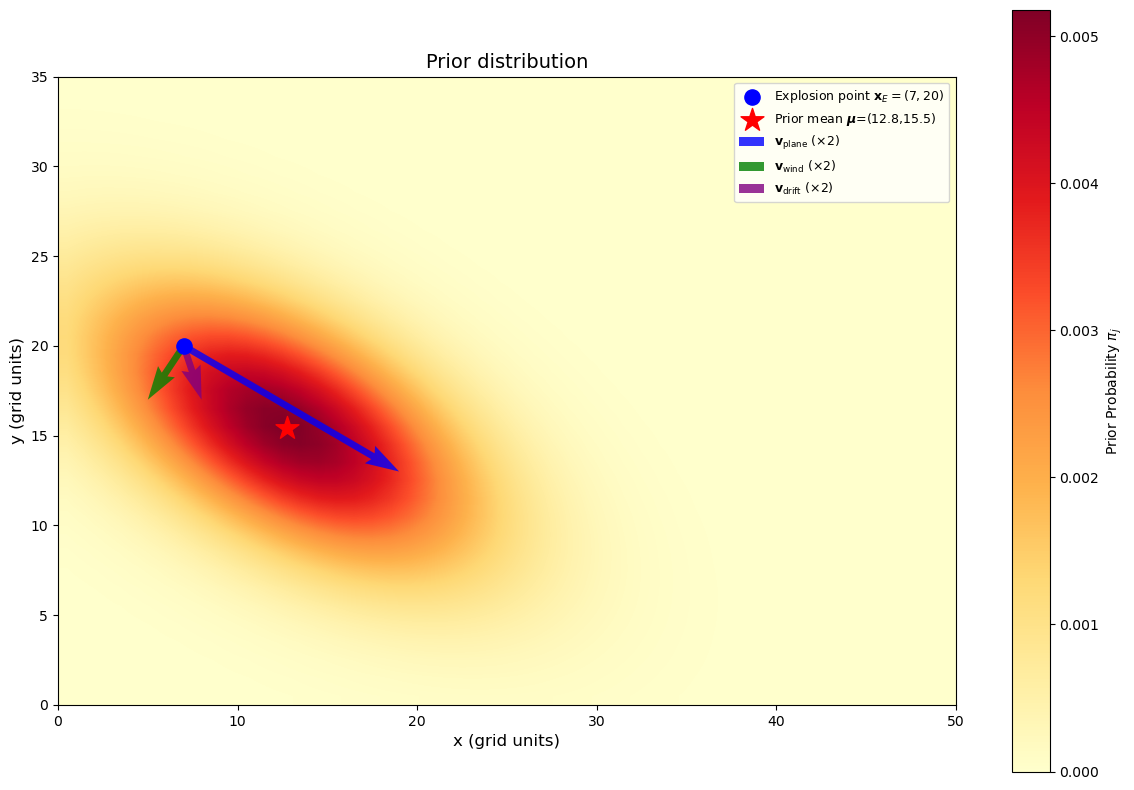

In [10]:
# Heatmap of prior
fig, ax = plt.subplots(figsize=(12, 8))
pivot = grid_df.pivot(index='y', columns='x', values='prior')
im = ax.imshow(pivot.values, origin='lower', extent=[0, Nx, 0, Ny], cmap="YlOrRd", aspect='equal', interpolation='bilinear')
plt.colorbar(im, ax=ax, label='Prior Probability $\\pi_j$')

ax.scatter(*x_E, color='blue', s=120, zorder=5, label='Explosion point $\\mathbf{x}_E=(7,20)$')
ax.scatter(*mu_prior, color='red', marker='*', s=300, zorder=5, label=f'Prior mean $\\boldsymbol{{\\mu}}$=({mu_prior[0]:.1f},{mu_prior[1]:.1f})')

scale = 2
ax.quiver(*x_E, *v_plane*scale, angles='xy', scale_units='xy', scale=1, color='blue', alpha=0.8, label='$\\mathbf{v}_{\\mathrm{plane}}$ (×2)')
ax.quiver(*x_E, *v_wind*scale,  angles='xy', scale_units='xy', scale=1, color='green', alpha=0.8, label='$\\mathbf{v}_{\\mathrm{wind}}$ (×2)')
ax.quiver(*x_E, *v_drift*scale, angles='xy', scale_units='xy', scale=1, color='purple', alpha=0.8, label='$\\mathbf{v}_{\\mathrm{drift}}$ (×2)')

ax.set_xlabel('x (grid units)', fontsize=12)
ax.set_ylabel('y (grid units)', fontsize=12)
ax.set_title('Prior distribution', fontsize=14)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0,Nx); ax.set_ylim(0,Ny)
plt.tight_layout()
plt.savefig('prior_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Task 2: Detection model

### Functional form: negative-exponential (Koopman)

We will model the conditional detection probability given coverage as:

$$\rho_{tj} = 1 - \exp\!\bigl(-e_t\,\kappa_j\bigr).$$

**Why this form?**
Koopman derived this model from 